<a href="https://colab.research.google.com/github/Jessica1842553/MCDpycd2026/blob/main/Tarea2_PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tarea 2 - Análisis de Texto  
### Jessica Lizeth Hernández Bracho 1842553



### Guiones de los episodios piloto ($1 \times 01$) de Malcolm in the Middle vs. Modern Family.

*Objetivo: Analizar y comparar la estructura lingüística y los rasgos estilísticos de dos producciones televisivas icónicas: **Malcolm in the Middle** (Linwood Boomer) y **Modern Family** (Christopher Lloyd y Steven Levitan).*

### 1. Carga de archivos

In [1]:
# Carga de texto del episodio uno de cada serie
with open("mitm_s1e1.txt", "r", encoding="utf-8") as f:
    texto_malcolm = f.read()

with open("mf_s1e1.txt", "r", encoding="utf-8") as f:
    texto_modern = f.read()

# Primeros caracteres
print("Malcolm:", texto_malcolm[:300])
print("Modern Family:", texto_modern[:300])

Malcolm: This is the world--

196 million square miles.

If I covered 100 square miles
an hour

every hour
for the rest of my life

I'd still only see half of it.

This is the left nostril
of my brother Reese.

It squeaks all night long.

These are
the freezing cold feet

of my little brother... Dewey.

This
Modern Family: [Claire]
Kids, breakfast!

Kids? [Sighs]
Phil, would you get them?
[Video Game Sounds]

Yeah. Just a sec.

Kids!

That is-
Okay.

Kids? Get down here!

Why are you guys yelling at us
when we're way upstairs?

Just text me.
All right.
That's not gonna happen.

And, wow! You're not
wearing that outfit


### 2. Limpieza y Tokenizacion

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [3]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
ps = PorterStemmer()

In [5]:
def tokens_clase(txt, idioma = 'english'):
    # 1. Quitar signos y pasar a minúsculas
    texto_limpio = re.sub(r'[^ɵ\w\s]', '', txt.lower())

    # 2. Cargar stopwords
    stop_words = set(stopwords.words(idioma))
    ruido_guiones = ['dont', 'im', 'youre', 'cant', 'ive', 'oh', 'hey', 'yeah', 'gonna', 'wanna', 'gotta', 'gon', 'wan', 'na', 'ta']
    for word in ruido_guiones:
        stop_words.add(word)

    # 3. Tokenizar y filtrar
    tokens_totales = word_tokenize(texto_limpio)
    texto_filtrado = [word for word in tokens_totales if word not in stop_words]

    tokens_stemmed = [ps.stem(palabra) for palabra in texto_filtrado]

    return tokens_stemmed

# Aplicamos la función a cada texto
tokens_malcolm = tokens_clase(texto_malcolm)
tokens_modern = tokens_clase(texto_modern)

# Resultado
print("Tokens Malcolm:", tokens_malcolm[:15])
print("Tokens Modern Family:", tokens_modern[:15])

Tokens Malcolm: ['world', '196', 'million', 'squar', 'mile', 'cover', '100', 'squar', 'mile', 'hour', 'everi', 'hour', 'rest', 'life', 'id']
Tokens Modern Family: ['clair', 'kid', 'breakfast', 'kid', 'sigh', 'phil', 'would', 'get', 'video', 'game', 'sound', 'sec', 'kid', 'okay', 'kid']


Se utilizó la librería `NLTK` para:

1. **Lectura de Archivos:** Carga de los guiones en texto plano (`.txt`), asegurando textos limpios.
2. **Normalización:** Conversión total de strings a minúsculas y remoción de caracteres especiales y signos de puntuación mediante expresiones regulares (`re.sub`).
3. **Tokenización:** Segmentación del texto corrido en unidades discretas de palabras (tokens) a través de `word_tokenize`.
4. **Filtrado de Palabras Vacías (*Stop Words*):** Remoción de conectores y artículos de alta frecuencia pero nulo valor semántico empleando el diccionario nativo en inglés de NLTK.
    * *Nota:* Se expandió la lista de stop words para mitigar el ruido sintáctico generado por el tokenizador al fragmentar contracciones informales propias de los guiones (ej. *gonna* a `gon` y `na`).
5. **Reducción de Desinencias (*Stemming*):** Aplicación del algoritmo `PorterStemmer` para reducir las flexiones de las palabras a sus raíces básicas y unificar el conteo de frecuencias.

### 3. Conteo de Frecuencias

In [6]:
import pandas as pd

In [7]:
# ANÁLISIS DE MALCOLM
df_malcolm = pd.DataFrame(tokens_malcolm, columns=['token'])
frec_malcolm = df_malcolm.value_counts().to_frame().reset_index()
frec_malcolm.columns = ['token', 'conteo']

print("TOP 10 PALABRAS MALCOLM")
print(frec_malcolm.head(10))

TOP 10 PALABRAS MALCOLM
     token  conteo
0  malcolm      33
1     okay      25
2     know      24
3       go      23
4     want      20
5     like      20
6      get      19
7     make      16
8      mom      15
9    right      14


In [8]:
# ANÁLISIS DE MODERN FAMILY
df_modern = pd.DataFrame(tokens_modern, columns=['token'])
frec_modern = df_modern.value_counts().to_frame().reset_index()
frec_modern.columns = ['token', 'conteo']

print("TOP 10 PALABRAS MODERN FAMILY")
print(frec_modern.head(10))

TOP 10 PALABRAS MODERN FAMILY
   token  conteo
0   know      33
1   okay      30
2   that      24
3   like      21
4    dad      21
5  right      19
6    say      18
7    get      18
8     uh      18
9   come      17


### 4. Métricas

- Conteo de Signos de Puntuación

In [9]:
# Contar exclamaciones e interrogaciones directamente en el texto original
print("ANÁLISIS DE SIGNOS DE PUNTUACIÓN")
print(f"Malcolm - Signos de Exclamación (!): {texto_malcolm.count('!')}")
print(f"Malcolm - Signos de Interrogación (?): {texto_malcolm.count('?')}")

print(f"\nModern Family - Signos de Exclamación (!): {texto_modern.count('!')}")
print(f"Modern Family - Signos de Interrogación (?): {texto_modern.count('?')}")

ANÁLISIS DE SIGNOS DE PUNTUACIÓN
Malcolm - Signos de Exclamación (!): 55
Malcolm - Signos de Interrogación (?): 89

Modern Family - Signos de Exclamación (!): 62
Modern Family - Signos de Interrogación (?): 104


Interpretación: Los datos demuestran un volumen superior tanto de signos de exclamación como de interrogación en el episodio piloto de **Modern Family**. Desde una perspectiva analítica, esto refleja el estilo de ritmo rápido y la estructura de enredos simultáneos del show. El piloto de *Modern Family* se caracteriza por la alta tensión cómica debido a malentendidos, preguntas constantes entre los protagonistas, y situaciones caóticas, lo que satura el guion de marcas expresivas y cuestionamientos interactivos.

- Mejor vocabulario de cada serie

In [10]:
# Fórmula: Palabras únicas / Palabras totales
voc_malcolm = len(set(tokens_malcolm)) / len(tokens_malcolm)
voc_modern = len(set(tokens_modern)) / len(tokens_modern)

print(f"Vocabulario de Malcolm: {voc_malcolm:.3f}")
print(f"Vocabulario de Modern Family: {voc_modern:.3f}")

Vocabulario de Malcolm: 0.423
Vocabulario de Modern Family: 0.400


Interpretación: El análisis estadístico reveló que **Malcolm in the Middle** exhibe una riqueza léxica superior (42.3% de palabras únicas) en comparación con *Modern Family* (40.0%). A pesar de que *Modern Family* cuenta con un elenco más amplio, el guion de *Malcolm* se apoya de forma masiva en el monólogo interno y la narración en primera persona del protagonista hacia la cámara.

### 5. n-Gramas (Bigramas) y Grafos de Palabras

In [11]:
from nltk import ngrams
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

In [12]:
# BIGRAMAS EN MALCOLM
# Generamos los bigramas a partir de la lista de tokens limpios
bigr_malcolm = list(ngrams(tokens_malcolm, 2))
# Contamos cuáles son los más comunes
topbigr_malcolm = Counter(bigr_malcolm).most_common(5)

print("TOP 5 BIGRAMAS MALCOLM")
for grama, conteo in topbigr_malcolm:
    print(f"{grama}: {conteo} veces")

TOP 5 BIGRAMAS MALCOLM
('wait', 'wait'): 5 veces
('hold', 'hand'): 4 veces
('spath', 'spath'): 3 veces
('go', 'special'): 3 veces
('special', 'class'): 3 veces


In [13]:
# BIGRAMAS EN MODERN FAMILY
bigr_modern = list(ngrams(tokens_modern, 2))
topbigr_modern = Counter(bigr_modern).most_common(5)

print("TOP 5 BIGRAMAS MODERN FAMILY")
for grama, conteo in topbigr_modern:
    print(f"{grama}: {conteo} veces")

TOP 5 BIGRAMAS MODERN FAMILY
('hi', 'hi'): 4 veces
('thank', 'thank'): 4 veces
('let', 'see'): 4 veces
('dad', 'dad'): 3 veces
('first', 'time'): 3 veces


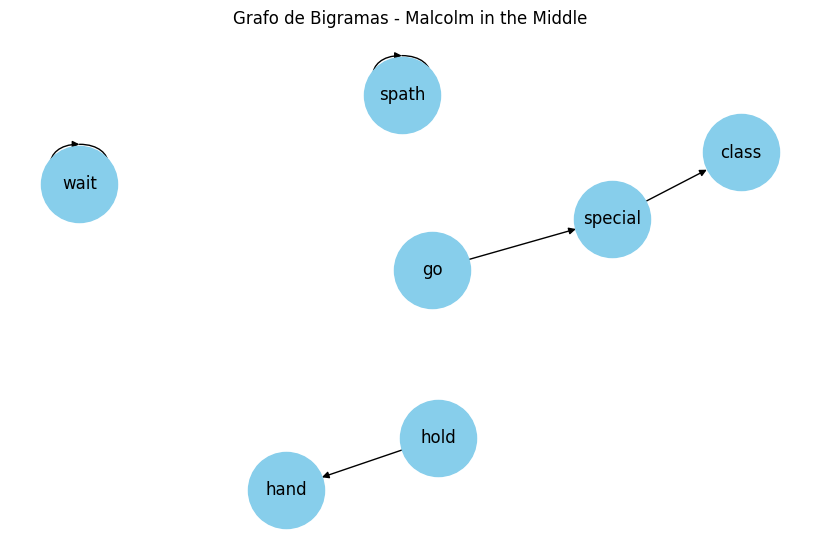

In [14]:
# Bigramas de Malcolm
G = nx.DiGraph()

# Agregamos los 5 bigramas más comunes al grafo
for grama, conteo in topbigr_malcolm:
    G.add_edge(grama[0], grama[1])

plt.figure(figsize=(8, 5))

pos = nx.spring_layout(G, k=0.8)
nx.draw(G, pos, with_labels=True, node_size=3000, font_size=12, node_color="skyblue")
plt.title("Grafo de Bigramas - Malcolm in the Middle")
plt.show()

En el grafo de *Malcolm*, la conexión cerrada y adyacente entre los nodos `special` y `class` representa un hallazgo crítico de la minería de texto. El algoritmo fue capaz de extraer de forma totalmente automatizada el núcleo argumental de la primera temporada.  
En *Malcolm*, la presencia del bucle en el token `wait` (*"wait, wait!"*) refleja urgencia y conflicto verbal.

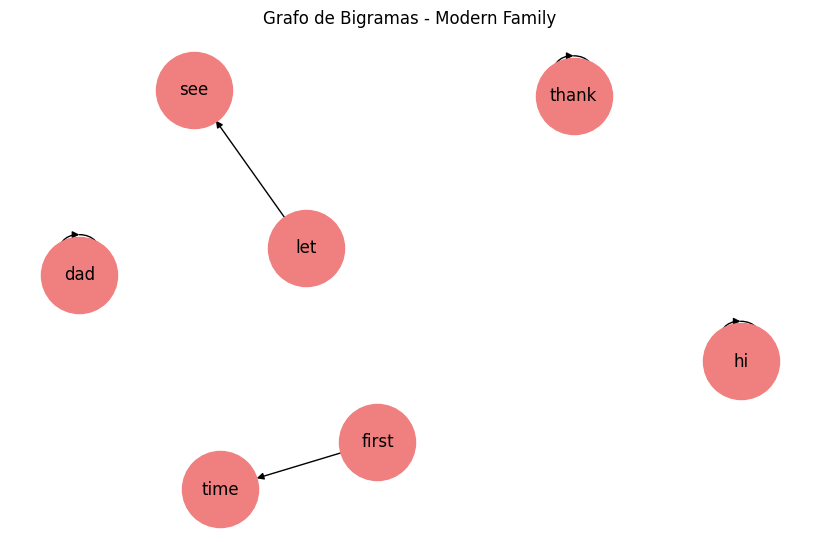

In [15]:
# Bigramas para Modern Family
G_modern = nx.DiGraph()

# Agregamos los 5 bigramas más comunes de Modern Family al grafo
for grama, conteo in topbigr_modern:
    G_modern.add_edge(grama[0], grama[1])

plt.figure(figsize=(8, 5))

pos = nx.spring_layout(G_modern, k=0.8)
nx.draw(G_modern, pos, with_labels=True, node_size=3000, font_size=12, node_color="lightcoral")
plt.title("Grafo de Bigramas - Modern Family")
plt.show()

### 6. Gráficas de Barras Comparativas

/tmp/ipykernel_766/3644574704.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(frec_malcolm.iloc[:10].token, rotation=45)
/tmp/ipykernel_766/3644574704.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(frec_modern.iloc[:10].token, rotation=45)


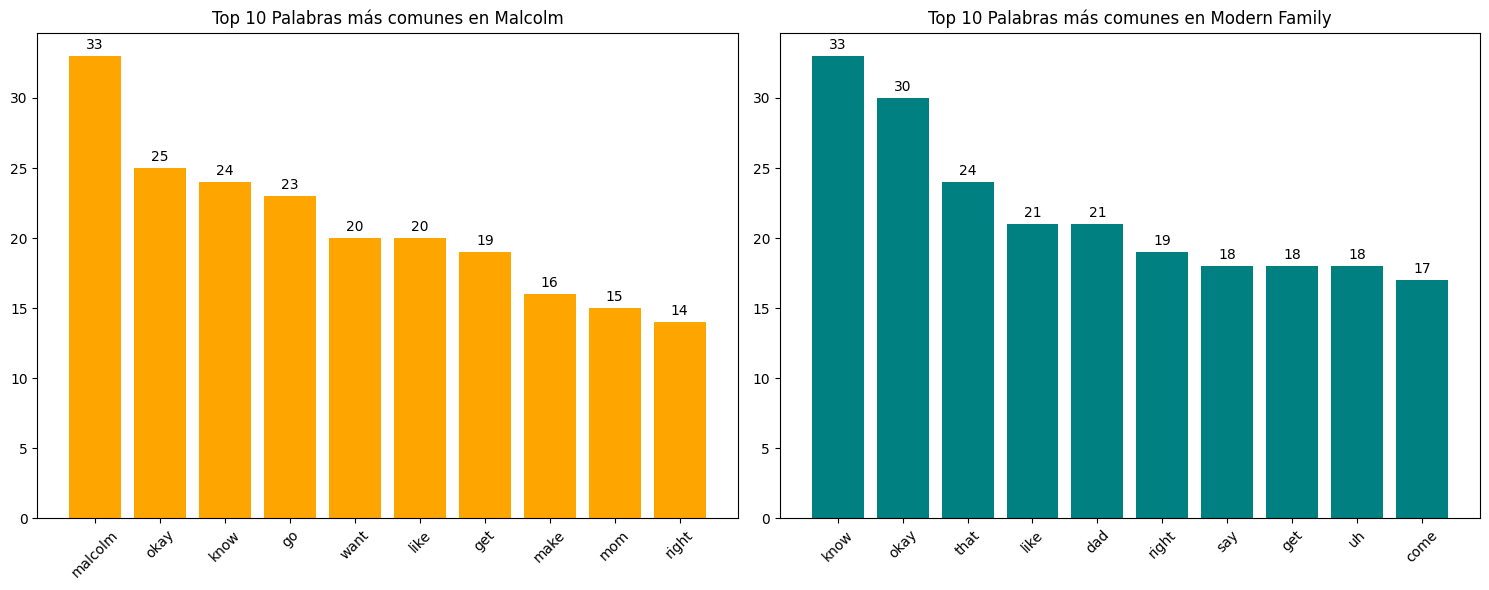

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Malcolm
barras1 = ax[0].bar(frec_malcolm.iloc[:10].token, frec_malcolm.iloc[:10].conteo, color='orange')
ax[0].set_title("Top 10 Palabras más comunes en Malcolm")
ax[0].set_xticklabels(frec_malcolm.iloc[:10].token, rotation=45)

ax[0].bar_label(barras1, padding=3)

# Gráfica 2: Modern Family
barras2 = ax[1].bar(frec_modern.iloc[:10].token, frec_modern.iloc[:10].conteo, color='teal')
ax[1].set_title("Top 10 Palabras más comunes en Modern Family")
ax[1].set_xticklabels(frec_modern.iloc[:10].token, rotation=45)

ax[1].bar_label(barras2, padding=3)

plt.tight_layout()
plt.show()

### 7. Bloques Temporales: Palabras distintas por etapa del episodio

Se dividió el episodio en cuatro bloques equivalentes de diálogos para simular la estructura clásica de tres actos y un clímax televisivo. Mediante el uso de agrupaciones `.groupby()` y conteos únicos `.nunique()`, se observó el flujo de palabras distintas a lo largo del episodio.

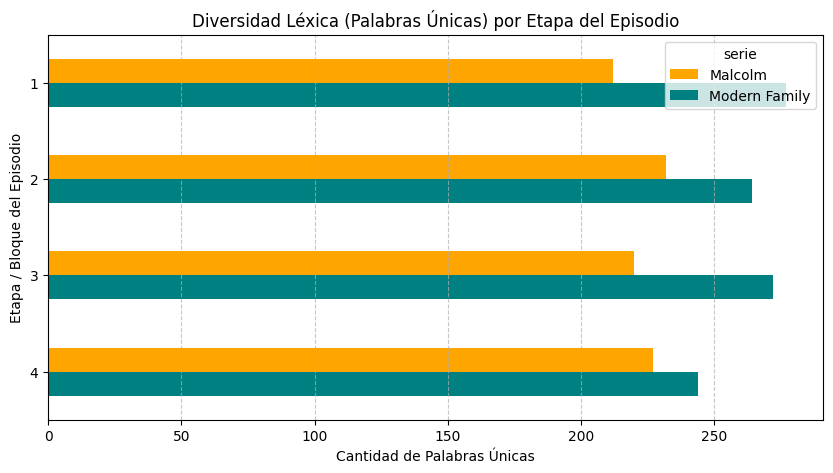

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PROCESAMIENTO DE MALCOLM POR BLOQUES
tokensbl_m = np.array_split(tokens_malcolm, 4)
bloques_m = []
for i, bloque in enumerate(tokensbl_m):
    for token in bloque:
        bloques_m.append({'token': token, 'bloque': i + 1, 'serie': 'Malcolm'})
df_bloques_m = pd.DataFrame(bloques_m)

# PROCESAMIENTO DE MODERN FAMILY POR BLOQUES
tokensbl_mf = np.array_split(tokens_modern, 4)
bloques_mf = []
for i, bloque in enumerate(tokensbl_mf):
    for token in bloque:
        bloques_mf.append({'token': token, 'bloque': i + 1, 'serie': 'Modern Family'})
df_bloques_mf = pd.DataFrame(bloques_mf)

# Union ambos DataFrames
df_bloques_total = pd.concat([df_bloques_m, df_bloques_mf])

# Calculo de palabras únicas (distintas) agrupando por Serie y Bloque
df_unicas = df_bloques_total.groupby(['serie', 'bloque'])['token'].nunique().unstack(level=0)

# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
df_unicas.plot(kind='barh', color=['orange', 'teal'], ax=plt.gca())
plt.title('Diversidad Léxica (Palabras Únicas) por Etapa del Episodio')
plt.xlabel('Cantidad de Palabras Únicas')
plt.ylabel('Etapa / Bloque del Episodio')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Interpretación**: Modern Family mantiene de manera consistente una mayor cantidad de palabras únicas en cada una de las cuatro etapas del episodio en comparación con Malcolm in the Middle.  
Malcolm se estabiliza en un rango de entre 210 y 230 palabras distintas por bloque, Modern Family muestra un pico de variedad en los actos intermedios (Bloques 2 y 3 con más de 260 palabras únicas).

### 8. Similitud Coseno Vectorial entre Series

Utilizando las funciones de distancia espacial distribuidas en la librería `scipy.spatial.distance`, se vectorizaron las distribuciones totales de frecuencia de las series en una matriz cruzada para obtener esta métrica.

In [22]:
from scipy.spatial.distance import cosine

# Generar la lista base unificada
datos_unif = (
    [{'token': t, 'serie': 'Malcolm'} for t in tokens_malcolm] +
    [{'token': t, 'serie': 'Modern_Family'} for t in tokens_modern]
)
dfpiv_series = pd.DataFrame(datos_unif)

# Crear la tabla cruzada
df_matriz = (
    dfpiv_series
    .groupby(["token", "serie"])
    ["token"]
    .agg(["count"])
    .reset_index()
    .pivot(index="token", columns="serie", values="count")
    .fillna(0)
)

# Definir la métrica
def similitud_coseno(a, b):
    distancia = cosine(a, b)
    return 1 - distancia

similitud = similitud_coseno(df_matriz['Malcolm'], df_matriz['Modern_Family'])

print("ANÁLISIS DE SIMILITUD VECTORIAL")
print(f"Distancia de Coseno: {cosine(df_matriz['Malcolm'], df_matriz['Modern_Family']):.4f}")
print(f"Similitud Coseno (Léxica): {similitud:.4f} ({similitud * 100:.2f}% de coincidencia)")

ANÁLISIS DE SIMILITUD VECTORIAL
Distancia de Coseno: 0.3586
Similitud Coseno (Léxica): 0.6414 (64.14% de coincidencia)


**Interpretación:** Un nivel de similitud del 64.14% refleja una coincidencia léxica notable entre ambas series.  
A pesar de las diferencias temporales (década de los 2000 vs. 2010) y de formato, ambas producciones comparten una base semántica común muy sólida.

### 9. Análisis de Sentimiento

Se implementó un análisis de sentimiento basado en el léxico lexicográfico AFINN-165 a partir de cruces relacionales del tipo `inner join` para evaluar la carga emocional de los diálogos de los pilotos.

In [25]:
# Descarga del léxico AFINN
lexicon = pd.read_table(
    'https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-en-165.txt',
    names = ['termino', 'sentimiento']
)

# Convertir tokens a DataFrames independientes
dftok_m = pd.DataFrame(tokens_malcolm, columns=['token'])
dftok_mf = pd.DataFrame(tokens_modern, columns=['token'])

# Ejecutar cruces matriciales
dfsent_m = pd.merge(left=dftok_m, right=lexicon, left_on="token", right_on="termino", how="inner")
dfsent_mf = pd.merge(left=dftok_mf, right=lexicon, left_on="token", right_on="termino", how="inner")

# Función de perfiles emocionales
def mostrar_perfil(df, nombre_serie):
    pos = round(100 * np.mean(df.sentimiento > 0), 2)
    neg = round(100 * np.mean(df.sentimiento < 0), 2)
    score_promedio = round(np.mean(df.sentimiento), 3)

    print(f"Perfil Emocional: {nombre_serie}")
    print(f"Carga Positiva: {pos}%")
    print(f"Carga Negativa: {neg}%")
    print(f"Puntuación Promedio de Sentimiento: {score_promedio}")
    print("-" * 55)

print("ANÁLISIS DE SENTIMIENTO COMPARATIVO")
mostrar_perfil(dfsent_m, "Malcolm in the Middle")
mostrar_perfil(dfsent_mf, "Modern Family")

ANÁLISIS DE SENTIMIENTO COMPARATIVO
Perfil Emocional: Malcolm in the Middle
Carga Positiva: 67.57%
Carga Negativa: 32.43%
Puntuación Promedio de Sentimiento: 0.605
-------------------------------------------------------
Perfil Emocional: Modern Family
Carga Positiva: 59.84%
Carga Negativa: 40.16%
Puntuación Promedio de Sentimiento: 0.389
-------------------------------------------------------


**Interpretación:**  
Malcolm in the Middle presenta un promedio de sentimiento significativamente más alto (0.605) y una mayor concentración de palabras positivas (67.57%).  
Se descubre que el piloto de Modern Family basa su comedia en la incomodidad, la frustración parental y el conflicto sutil (reflejado en el 40.16% de carga negativa)